In [1]:
print('Notebook ready!')

Notebook ready!


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/home/rhythm/Documents/netguard-ai/backend/data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

print("Original shape:", df.shape)

# Step 1 — Inf values ko NaN se replace karo
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 2 — NaN rows drop karo
df.dropna(inplace=True)

# Step 3 — Duplicate rows drop karo
df.drop_duplicates(inplace=True)

print("Cleaned shape:", df.shape)
print("\nLabel distribution after cleaning:")
print(df['Label'].value_counts())

Original shape: (225745, 79)
Cleaned shape: (223082, 79)

Label distribution after cleaning:
Label
DDoS      128014
BENIGN     95068
Name: count, dtype: int64


In [3]:
from sklearn.preprocessing import LabelEncoder

# Label encode karo — BENIGN=0, DDoS=1
le = LabelEncoder()
df['Label_enc'] = le.fit_transform(df['Label'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

# Features — Label columns hataao
X = df.drop(columns=['Label', 'Label_enc'])
y = df['Label_enc']

print("\nFeatures shape:", X.shape)
print("Labels shape:", y.shape)

Label mapping:
  BENIGN → 0
  DDoS → 1

Features shape: (223082, 78)
Labels shape: (223082,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducible results
    stratify=y            # class ratio maintain karo
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nTrain label distribution:")
print(y_train.value_counts())

Training samples: 178465
Testing samples: 44617

Train label distribution:
Label_enc
1    102411
0     76054
Name: count, dtype: int64


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import time

print("Training Random Forest...")
start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,     # 100 trees
    max_depth=20,         # overfitting rokta hai
    random_state=42,
    n_jobs=-1             # saare CPU cores use karo
)

rf.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training complete in {elapsed:.1f} seconds")

# Evaluate
y_pred = rf.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training Random Forest...
Training complete in 13.5 seconds

--- Classification Report ---
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617



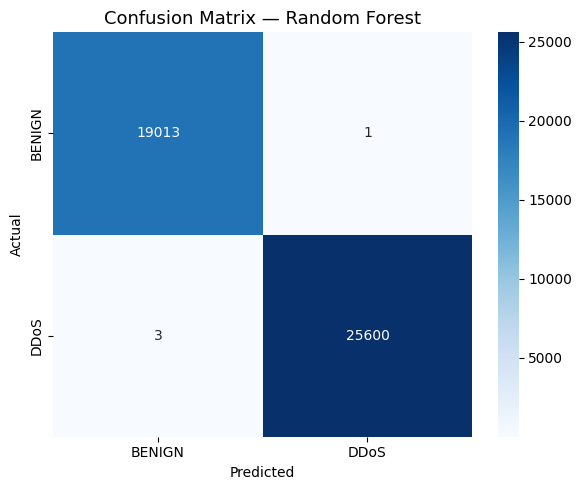

Saved!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/home/rhythm/Documents/netguard-ai/notebooks/confusion_matrix.png')
plt.show()
print("Saved!")


In [7]:
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest...")

# Sirf normal traffic pe train karo
X_normal = X_train[y_train == 0]

iso = IsolationForest(
    n_estimators=100,
    contamination=0.1,    # 10% anomaly expected
    random_state=42,
    n_jobs=-1
)
iso.fit(X_normal)

# Test karo — Isolation Forest -1 = anomaly, 1 = normal
iso_pred = iso.predict(X_test)
iso_pred_binary = (iso_pred == -1).astype(int)  # -1 ko 1 (attack) mein convert

print("\n--- Isolation Forest Report ---")
print(classification_report(y_test, iso_pred_binary, target_names=le.classes_))

Training Isolation Forest...

--- Isolation Forest Report ---
              precision    recall  f1-score   support

      BENIGN       0.48      0.90      0.62     19014
        DDoS       0.78      0.27      0.40     25603

    accuracy                           0.53     44617
   macro avg       0.63      0.58      0.51     44617
weighted avg       0.65      0.53      0.49     44617



In [8]:
import joblib
import os

os.makedirs('/home/rhythm/Documents/netguard-ai/backend/models', exist_ok=True)

# Random Forest save
joblib.dump(rf, '/home/rhythm/Documents/netguard-ai/backend/models/random_forest.joblib')

# Isolation Forest save
joblib.dump(iso, '/home/rhythm/Documents/netguard-ai/backend/models/isolation_forest.joblib')

# Label Encoder save
joblib.dump(le, '/home/rhythm/Documents/netguard-ai/backend/models/label_encoder.joblib')

# Feature names save — API mein kaam aayega
feature_names = X.columns.tolist()
joblib.dump(feature_names, '/home/rhythm/Documents/netguard-ai/backend/models/feature_names.joblib')

print("Models saved:")
for f in os.listdir('/home/rhythm/Documents/netguard-ai/backend/models'):
    size = os.path.getsize(f'/home/rhythm/Documents/netguard-ai/backend/models/{f}')
    print(f"  {f} — {size/1024/1024:.1f} MB")

Models saved:
  feature_names.joblib — 0.0 MB
  random_forest.joblib — 1.4 MB
  label_encoder.joblib — 0.0 MB
  isolation_forest.joblib — 0.9 MB
